In [ ]:
import pandas as pd
import re
import nltk
import string

In [ ]:
data = pd.read_csv(
    "/content/IMDB Dataset.csv",
    engine='python',
    on_bad_lines='skip',
    encoding='latin1'
)

In [ ]:
data.shape

(50000, 2)

In [ ]:
data.columns

Index(['review', 'sentiment'], dtype='object')

In [ ]:
# find unique values in sentiment
data.loc[:,'sentiment'].unique()

array(['positive', 'negative'], dtype=object)

In [ ]:
# convert positive-->1 ,negative =0
data.loc[:,'Sentiment']= data.loc[:,'sentiment'].map({'positive':1,'negative':0})

#text cleaning


In [ ]:
data.loc[1,'review']

'A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams\' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master\'s of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional \'dream\' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell\'s murals decorating every surface) are terribly well d

In [ ]:
def clean_text(text):
  # convert upper to lower
  text = text.lower()
  # remove all html tags
  text = re.sub(r'<.*?>',' ',text)
  #  include only A-z,a-z,!,?
  text = re.sub(r'[^a-zA-Z!?]',' ',text)
  # remove white spaces
  text =re.sub(r'\s+',' ',text).strip()
  return text

In [ ]:
data.loc[:,'cleaned_review']=data.loc[:,'review'].apply(clean_text)

In [ ]:
data.loc[1,'cleaned_review']

'a wonderful little production the filming technique is very unassuming very old time bbc fashion and gives a comforting and sometimes discomforting sense of realism to the entire piece the actors are extremely well chosen michael sheen not only has got all the polari but he has all the voices down pat too! you can truly see the seamless editing guided by the references to williams diary entries not only is it well worth the watching but it is a terrificly written and performed piece a masterful production about one of the great master s of comedy and his life the realism really comes home with the little things the fantasy of the guard which rather than use the traditional dream techniques remains solid then disappears it plays on our knowledge and our senses particularly with the scenes concerning orton and halliwell and the sets particularly of their flat with halliwell s murals decorating every surface are terribly well done'

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(data['cleaned_review'])
X = tokenizer.texts_to_sequences(data['cleaned_review'])

In [ ]:
X[0]

[28,
 4,
 1,
 77,
 2037,
 46,
 1051,
 11,
 100,
 149,
 41,
 3056,
 394,
 20,
 229,
 29,
 3173,
 32,
 25,
 204,
 14,
 10,
 6,
 613,
 47,
 592,
 17,
 68,
 1,
 88,
 148,
 11,
 3218,
 68,
 44,
 3056,
 13,
 91,
 2,
 135,
 4,
 559,
 61,
 265,
 8,
 204,
 37,
 1,
 647,
 141,
 1723,
 68,
 10,
 6,
 23,
 3,
 116,
 16,
 1,
 2306,
 40,
 10,
 116,
 2569,
 56,
 17,
 5,
 1455,
 371,
 40,
 559,
 91,
 6,
 3783,
 8,
 1,
 355,
 356,
 4,
 1,
 647,
 7,
 6,
 432,
 3056,
 14,
 11,
 6,
 1,
 357,
 5,
 1,
 2515,
 1032,
 7,
 2685,
 1400,
 22,
 518,
 34,
 4618,
 2436,
 4,
 1,
 1183,
 115,
 30,
 1,
 27,
 2881,
 2,
 385,
 36,
 6,
 23,
 297,
 22,
 1,
 4836,
 2885,
 518,
 6,
 340,
 5,
 107,
 4992,
 2424,
 2,
 52,
 36,
 324,
 2,
 25,
 112,
 223,
 240,
 9,
 60,
 132,
 1,
 280,
 1319,
 4,
 1,
 116,
 6,
 679,
 5,
 1,
 192,
 11,
 7,
 266,
 115,
 77,
 274,
 569,
 21,
 2981,
 818,
 182,
 1290,
 4123,
 16,
 2471,
 1216,
 818,
 1420,
 818,
 865,
 3056,
 152,
 21,
 939,
 184,
 1,
 88,
 394,
 9,
 123,
 210,
 3218,
 68,
 14,
 36,

In [ ]:
y= data.loc[:,'Sentiment']
y

,Sentiment
0,1
1,1
2,1
3,0
4,1
...,...
49995,1
49996,0
49997,0
49998,0


In [ ]:
import pickle

# Save tokenizer
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)


#LSTM

In [ ]:
from tensorflow.keras.layers import LSTM

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,SimpleRNN,Dense

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
# padding process to make length of all the sentences to be same
from tensorflow.keras.preprocessing.sequence import pad_sequences
x_train = pad_sequences(x_train,maxlen=100,padding='post',truncating='post')
x_test = pad_sequences(x_test,maxlen=100,padding='post',truncating='post')

In [ ]:
model = Sequential()
model.add(Embedding(input_dim =5000,output_dim=128))
model.build(input_shape=(None,100))
model.add(LSTM(64))
model.add(Dense(1,activation='sigmoid'))

In [ ]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [ ]:
model.fit(x_train,y_train,epochs=20,batch_size=64,verbose=1)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 142ms/step - accuracy: 0.9996 - loss: 0.0044
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 142ms/step - accuracy: 1.0000 - loss: 4.3704e-04
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - accuracy: 0.9803 - loss: 0.0547
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 149ms/step - accuracy: 0.9870 - loss: 0.0487
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - accuracy: 0.9988 - loss: 0.0082
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 153ms/step - accuracy: 0.9996 - loss: 0.0060
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 121ms/step - accuracy: 1.0000 - loss: 0.0018
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 154ms/step - accuracy: 1.0000 - loss: 0.0012
Epoch 9/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - accuracy: 1.0000 - loss: 9.7705e-04
Epoch 10/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 135ms/step - accuracy: 1.0000 - loss: 7.9379e-04
Epoch 11/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - accuracy: 1.0000 - loss: 6.8671e-04
Epoch 12/20
40/40 ━━━━━━━━━━━━━━━━━━

In [ ]:
loss, accuracy = model.evaluate(x_test, y_test)

print("Loss:", loss)
print("Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.5170 - loss: 0.6929
Loss: 0.6928688287734985
Accuracy: 0.5170000195503235


In [ ]:

def predict_sentiment(text):
    # Step 1: tokenize
    seq = tokenizer.texts_to_sequences([text])

    # Step 2: padding
    padded = pad_sequences(seq, maxlen=100)

    # Step 3: prediction
    pred = model.predict(padded)[0][0]

    # Step 4: label
    #pred = round(pred)
    print(pred)
    if pred > 0.5:
        return "Positive 😊"
    else:
        return "Negative 😞"

In [ ]:
predict_sentiment("Movie is very good to watch.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
0.6592095


'Positive 😊'

In [ ]:
predict_sentiment(" not intrested in such matter")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
0.37135002


'Negative 😞'

In [ ]:
model.save("lstm_model.h5")

#CNN

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("olafkrastovski/handwritten-digits-0-9")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'handwritten-digits-0-9' dataset.
Path to dataset files: /kaggle/input/handwritten-digits-0-9


In [ ]:
import os
print(os.listdir(path))

['7', '2', '5', '8', '0', '3', '1', '4', '9', '6']


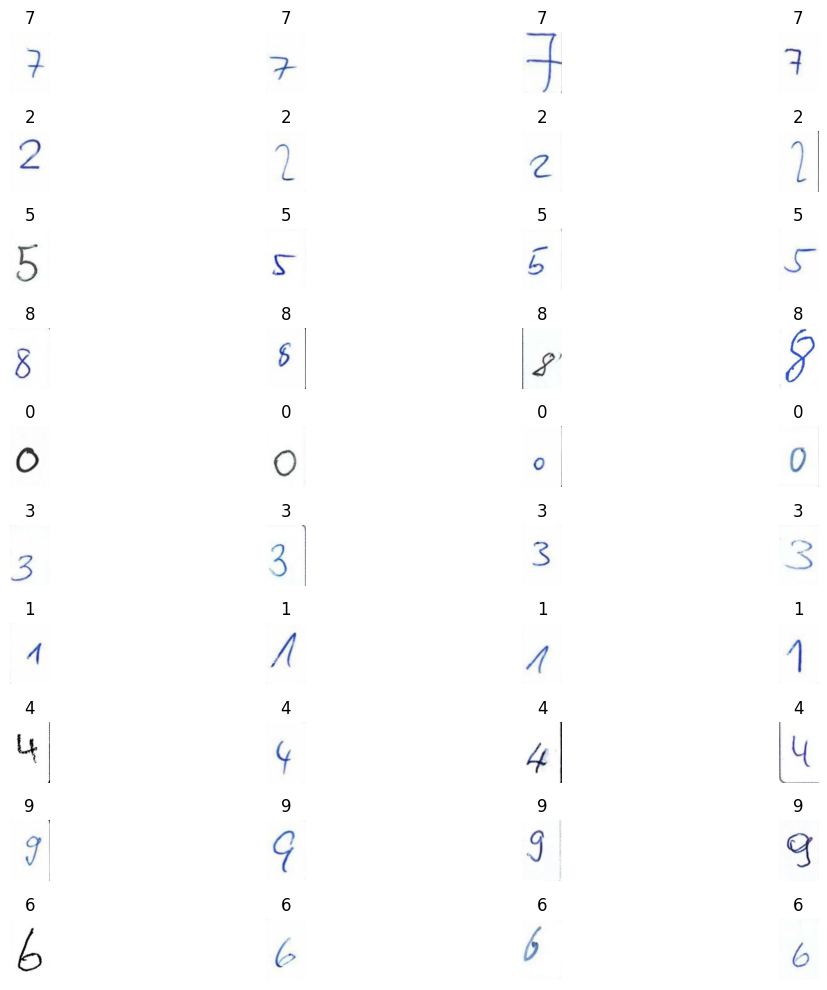

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

base_path = os.path.join(path,"/kaggle/input/handwritten-digits-0-9")
plt.figure(figsize=(12, 10))
i=1

for class_name in os.listdir(base_path):
  class_path = os.path.join(base_path, class_name)
  #print(class_path)

  if os.path.isdir(class_path):
        images = os.listdir(class_path)[:4]

        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            img = Image.open(img_path)

            plt.subplot(10,4, i)  # 5 classes × 3 images
            plt.imshow(img)
            plt.title(class_name)
            plt.axis('off')

            i += 1

plt.tight_layout()
plt.show()

In [ ]:

base_path = os.path.join(path, "/kaggle/input/handwritten-digits-0-9")

for class_name in os.listdir(base_path):
    class_path = os.path.join(base_path, class_name)

    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        print(class_name, ":", count)

7 : 2116
2 : 2233
5 : 2126
8 : 2085
0 : 2236
3 : 2202
1 : 2241
4 : 2179
9 : 2016
6 : 2121


In [ ]:
import pandas as pd

base_path = os.path.join(path,"/kaggle/input/handwritten-digits-0-9")


data = []

for label in os.listdir(base_path):
    class_path = os.path.join(base_path, label)

    if os.path.isdir(class_path):
        for img in os.listdir(class_path):
            img_path = os.path.join(class_path, img)
            data.append([img_path, label])

df = pd.DataFrame(data, columns=["image_path", "label"])
df

,image_path,label
0,/kaggle/input/handwritten-digits-0-9/7/Seven_f...,7
1,/kaggle/input/handwritten-digits-0-9/7/Seven_f...,7
2,/kaggle/input/handwritten-digits-0-9/7/Seven_f...,7
3,/kaggle/input/handwritten-digits-0-9/7/Seven_f...,7
4,/kaggle/input/handwritten-digits-0-9/7/Seven_f...,7
...,...,...
21550,/kaggle/input/handwritten-digits-0-9/6/Six_ful...,6
21551,/kaggle/input/handwritten-digits-0-9/6/Six_ful...,6
21552,/kaggle/input/handwritten-digits-0-9/6/Six_ful...,6
21553,/kaggle/input/handwritten-digits-0-9/6/Six_ful...,6


In [ ]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
df

,image_path,label
0,/kaggle/input/handwritten-digits-0-9/0/Zero_fu...,0
1,/kaggle/input/handwritten-digits-0-9/3/Three_f...,3
2,/kaggle/input/handwritten-digits-0-9/2/Two_ful...,2
3,/kaggle/input/handwritten-digits-0-9/3/Three_f...,3
4,/kaggle/input/handwritten-digits-0-9/9/Nine_fu...,9
...,...,...
21550,/kaggle/input/handwritten-digits-0-9/3/Three_f...,3
21551,/kaggle/input/handwritten-digits-0-9/3/Three_f...,3
21552,/kaggle/input/handwritten-digits-0-9/5/Five_fu...,5
21553,/kaggle/input/handwritten-digits-0-9/7/Seven_f...,7


In [ ]:
train_size = int(0.7 * len(df))
val_size = int(0.15 * len(df))
test_size = int(0.15*len(df))
print(f"train_size:{train_size} -----val_size:{val_size}----test_size:{test_size}")

train_data = df.iloc[:train_size]
# df.iloc[:,52500]
val_data = df.iloc[train_size:train_size + val_size]
# df.iloc[52500:52500+11250]
test_data = df.iloc[train_size + val_size:]
# df.iloc[52500+11250:]

# Display the sizes of each set
print(f'Training set size: {len(train_data)}')
print(f'Validation set size: {len(val_data)}')
print(f'Test set size: {len(test_data)}')

train_size:15088 -----val_size:3233----test_size:3233
Training set size: 15088
Validation set size: 3233
Test set size: 3234


In [ ]:
image_path = df["image_path"][0]
image = Image.open(image_path)
width, height = image.size
print(f"height,width:{height,width}")

height,width:(140, 90)


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
batch_size = 32
img_height = 128
img_width = 128

In [ ]:
# Normalization
data_generator = ImageDataGenerator(
    rescale=1.0/255, # Normalization: Pixel values go from 0–255 → 0–1
    rotation_range=40, #Randomly rotates image up to ±40 degrees
    width_shift_range=0.2, #Moves image left/right by 20%
    height_shift_range=0.2, # Moves image up/down by 20%
    shear_range=0.2, # Slants the image (like pushing it sideways)
    zoom_range=0.2, # Zoom in/out randomly
    horizontal_flip=True, #Flips image left ↔ right
    fill_mode='nearest' #This fills those gaps using nearest pixels
)

In [ ]:
# train data
train_generator = data_generator.flow_from_dataframe(
  dataframe=train_data,
  x_col="image_path",
  y_col="label",
  target_size=(img_height, img_width),
  batch_size=batch_size,
  class_mode="categorical",
  shuffle=True,
  seed=42
)

Found 15088 validated image filenames belonging to 10 classes.


In [ ]:
# test generator
test_generator = data_generator.flow_from_dataframe(
  dataframe=test_data,
  x_col="image_path",
  y_col="label",
  target_size=(img_height, img_width),
  batch_size=batch_size,
  class_mode="categorical",
  shuffle=True,
  seed=42
)

Found 3234 validated image filenames belonging to 10 classes.


In [ ]:
# validation generator
validation_generator = data_generator.flow_from_dataframe(
  dataframe=val_data,
  x_col="image_path",
  y_col="label",
  target_size=(img_height, img_width),
  batch_size=batch_size,
  class_mode="categorical",
  shuffle=True,
  seed=42
)



Found 3233 validated image filenames belonging to 10 classes.


In [ ]:
for image_batch, labels_batch in train_generator:
    print(f"Train Shape: {image_batch.shape} (Batches = {len(train_generator)})")
    print(f"Train Label Shape: {labels_batch.shape}\n")
    break

for image_batch, labels_batch in validation_generator:
    print(f"Validation Shape: {image_batch.shape} (Batches = {len(validation_generator)})")
    print(f"Validation Label Shape: {labels_batch.shape}\n")
    break

for image_batch, labels_batch in test_generator:
    print(f"Test Shape: {image_batch.shape} (Batches = {len(test_generator)})")
    print(f"Test Label Shape: {labels_batch.shape}\n")
    break

Train Shape: (32, 128, 128, 3) (Batches = 472)
Train Label Shape: (32, 10)

Validation Shape: (32, 128, 128, 3) (Batches = 102)
Validation Label Shape: (32, 10)

Test Shape: (32, 128, 128, 3) (Batches = 102)
Test Label Shape: (32, 10)



In [ ]:
from tensorflow.keras import layers,models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import categorical_crossentropy

In [ ]:
n_classes= 10
cnn_model = models.Sequential([
    layers.Input(shape=(128,128,3)),
    layers.Conv2D(32,kernel_size= (3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size= (3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size= (3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(n_classes,activation='softmax')])

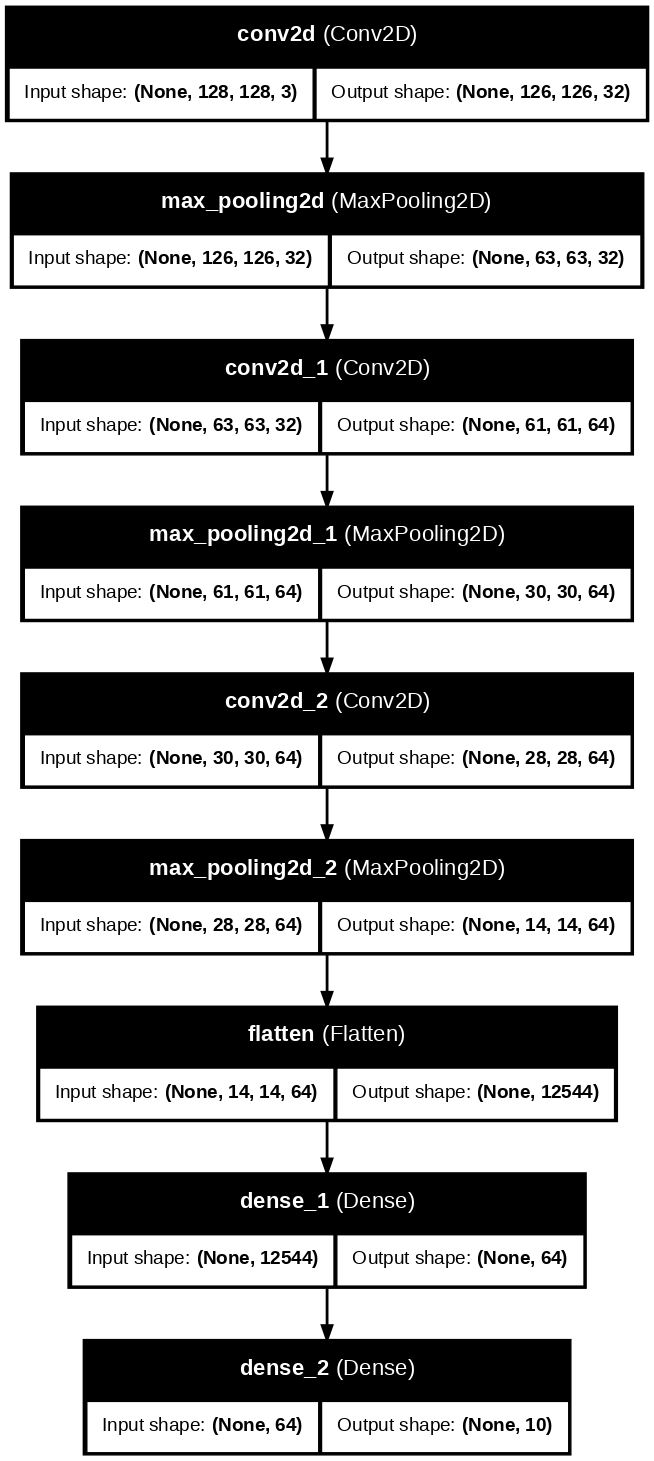

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(cnn_model, to_file='model_plot.png', show_shapes=True, show_layer_names=True, dpi=100, expand_nested=True)

In [ ]:
cnn_model.compile(loss=categorical_crossentropy,
                  optimizer=Adam(),
                  metrics=['accuracy'])

In [ ]:
cnn_model = models.Sequential([
    layers.Input(shape=(128,128,3)),
    layers.Conv2D(32,kernel_size= (3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size= (3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size= (3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(n_classes,activation='softmax')])
cnn_model.compile(loss=categorical_crossentropy,
                  optimizer=Adam(),
                  metrics=['accuracy'])
Cnn = cnn_model.fit(train_generator,
                    epochs=30,validation_data=validation_generator,
                    verbose=1)

Epoch 1/30
 11/472 ━━━━━━━━━━━━━━━━━━━━ 8:23 1s/step - accuracy: 0.1082 - loss: 2.3994   

KeyboardInterrupt: 

In [ ]:
train_loss, train_accuracy = cnn_model.evaluate(train_generator, verbose=1)
print(f'Training accuracy: {train_accuracy:.4f}')

# Evaluate on the test data
test_loss, test_accuracy = cnn_model.evaluate(test_generator, verbose=1)
print(f'Test accuracy: {test_accuracy:.4f}')

472/472 ━━━━━━━━━━━━━━━━━━━━ 209s 440ms/step - accuracy: 0.8688 - loss: 0.4035
Training accuracy: 0.8688
102/102 ━━━━━━━━━━━━━━━━━━━━ 44s 433ms/step - accuracy: 0.8779 - loss: 0.3747
Test accuracy: 0.8779


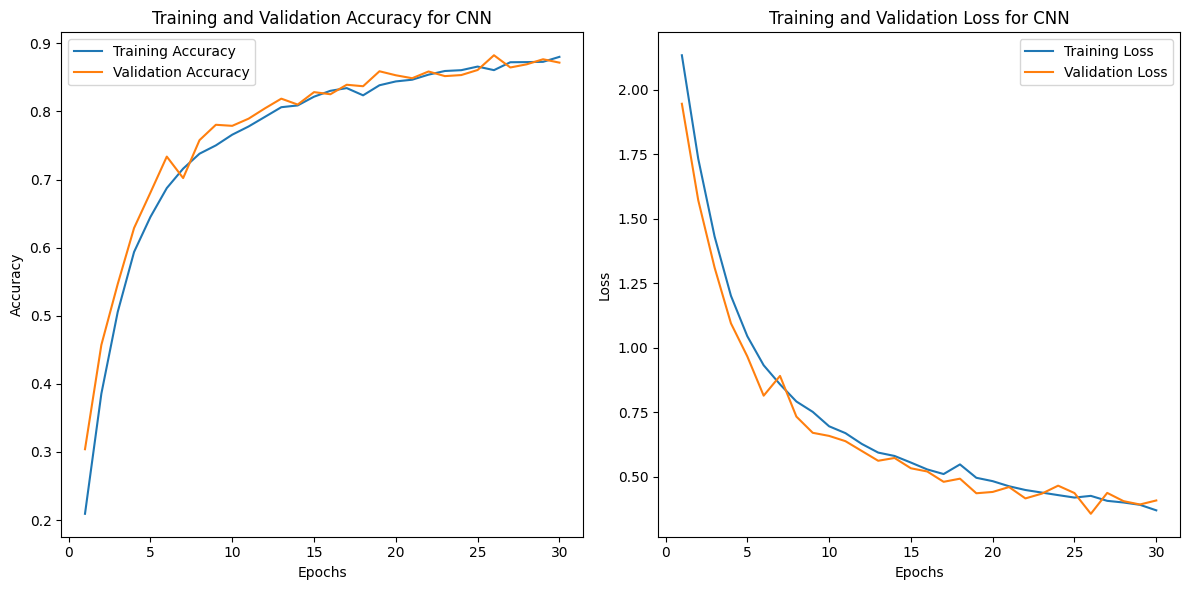

In [ ]:
# Retrieve metrics from the training history
acc = Cnn.history['accuracy']
val_acc = Cnn.history['val_accuracy']
loss = Cnn.history['loss']
val_loss = Cnn.history['val_loss']

epochs_range = range(1, len(acc) + 1)

# Plot accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy for CNN')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss for CNN')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:

cnn_model.save("cnn_model.h5")




NameError: name 'cnn_model' is not defined